In [ ]:
#import needed python library  

import os
import pandas as pd 
import numpy as np 
import matplotlib.pylab as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score



os.chdir ("C:\\Users\\junos\\OneDrive\\Documents\\BusinessAnalyticsModel")

print(os.getcwd())
plt.show()

C:\Users\junos\OneDrive\Documents\BusinessAnalyticsModel


In [5]:
# Load cleaned dataset
df = pd.read_csv('Module4/cleaned_Shoping_behavior_dataset.csv')

# Review dataset
print(df.shape)
df.info()
df.describe()
df.head()

(3900, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


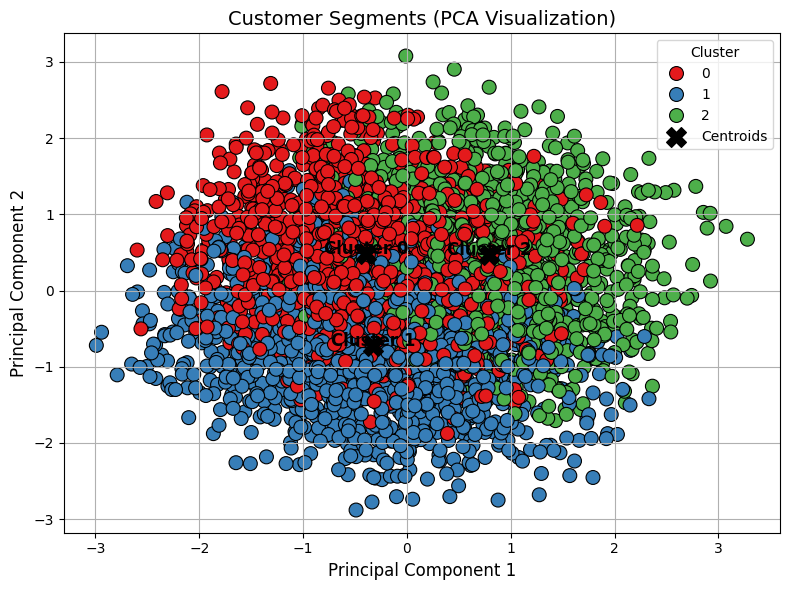

In [6]:
#  Selecting  numerical values for clustering         
features = df.select_dtypes(include=['float64', 'int64'])

# standadize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

# applying KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(scaled_data)

# applying PCA to reduce dimensionality
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)

# creating a dataframe with the PCA results and clusters labels
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

# map the KMeans centroids to the PCA components
centroids = pca.transform(kmeans.cluster_centers_)

# Plot the PCA visualization
plt.figure(figsize=(8 , 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=pca_df, palette='Set1', s=100, edgecolor='k')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], s=200, c='black', marker='X', label='Centroids')

# Annotate the centroids
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Cluster {i}', fontsize=12, ha='center', color='black', fontweight='bold')

#Title and labels
plt.title('Customer Segments (PCA Visualization)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster', loc='best')

#Display the grid and layout
plt.grid(True)
plt.tight_layout()
plt.show()

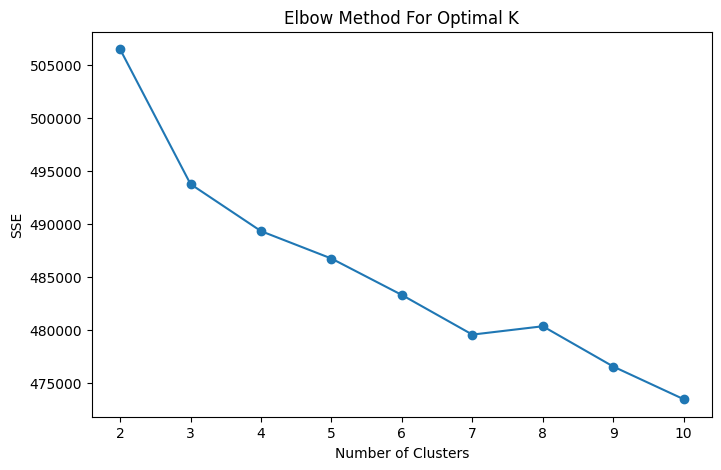

In [7]:
# Encode categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

# Scale features
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

# Elbow Method
sse = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    sse.append(kmeans.inertia_)

# Plot SSE
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sse, marker='o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()

In [8]:
# Use optimal cluster count (e.g., 4)
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster to original df
df['Cluster'] = clusters

# Evaluate with Silhouette Score
score = silhouette_score(scaled_data, clusters)
print(f'Silhouette Score: {score:.3f}')

Silhouette Score: 0.020


binary classification using Logistic Regression

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#features and target variable
X = df.drop(columns=['Subscription Status', 'Customer ID'])
y = df['Subscription Status']

#encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)  


X = pd.get_dummies(X, drop_first=True)

#scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train a Logistic Regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7961538461538461
              precision    recall  f1-score   support

           0       0.90      0.80      0.85       558
           1       0.61      0.77      0.68       222

    accuracy                           0.80       780
   macro avg       0.76      0.79      0.77       780
weighted avg       0.82      0.80      0.80       780



Random Forest Classifier

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_rf_pred = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Accuracy:", accuracy_score(y_test, y_rf_pred))
print(classification_report(y_test, y_rf_pred))

# Feature importance
feature_importance = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=['Importance']).sort_values('Importance', ascending=False)
print("\nFeature Importance:\n", feature_importance)


Random Forest Accuracy: 0.808974358974359
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       558
           1       0.61      0.88      0.72       222

    accuracy                           0.81       780
   macro avg       0.78      0.83      0.79       780
weighted avg       0.85      0.81      0.82       780


Feature Importance:
                        Importance
Discount Applied_Yes     0.161432
Promo Code Used_Yes      0.158468
Cluster                  0.125748
Purchase Amount (USD)    0.039442
Gender_Male              0.038464
...                           ...
Location_Maine           0.001298
Location_Rhode Island    0.001277
Location_Connecticut     0.001238
Location_Arizona         0.001236
Location_South Dakota    0.001138

[130 rows x 1 columns]


Gradient Boosting Classifier

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize and train the Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_gb_pred = gb_model.predict(X_test)

# Evaluate the model
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_gb_pred))
print(classification_report(y_test, y_gb_pred))


Gradient Boosting Accuracy: 0.8294871794871795
              precision    recall  f1-score   support

           0       0.96      0.79      0.87       558
           1       0.64      0.92      0.76       222

    accuracy                           0.83       780
   macro avg       0.80      0.86      0.81       780
weighted avg       0.87      0.83      0.84       780



Feature Importance 

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop 10 Important Features:\n", feature_importance.head(10))



Top 10 Important Features:
                        Feature  Importance
118        Promo Code Used_Yes    0.729466
117       Discount Applied_Yes    0.130565
1        Purchase Amount (USD)    0.015662
3           Previous Purchases    0.013675
0                          Age    0.011188
2                Review Rating    0.010022
4                      Cluster    0.007711
27   Item Purchased_Sunglasses    0.004051
123       Payment Method_Venmo    0.003934
112      Shipping Type_Express    0.003706
